# Cell - cell interaction with Liana (inflow and MOFA FLEX factorization)

In [5]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns


In [ ]:
# Load RNA data:

#/g/stegle/aivazidis/data/glioma_xenium/master_gbm_nucFiltered_scvi_annotated_new_50k.h5ad is the old one, 
# /g/stegle/aivazidis/data/glioma_xenium/master_gbm_nucFiltered_scvi_annotated_new.h5ad is the new one

data_directory = ("/g/stegle/aivazidis/data/glioma_xenium/rna_metacells_leiden_23072026nn20res180.h5ad")
#data_directory=("/g/stegle/aivazidis/data/glioma_xenium/master_gbm_nucFiltered_scvi_annotated_new.h5ad")
#adata_full=sc.read_h5ad(full_data)
adata_rna = sc.read_h5ad(data_directory)


adata_rna.var_names[:10]
adata_rna.obs_names[:10]
adata_rna
#adata_full
#keep

In [ ]:
#builds a spatial connectivity matrix W_ij
adata_rna.obsm["X_spatial_coords"] = adata_rna.obs[["cell_centroid_x", "cell_centroid_y"]].to_numpy()

#keep

In [ ]:
sc.pl.embedding(
    adata_rna,
    basis="X_spatial_coords",
    color=["sample_id", "region", "cell_type", "leiden"],
    size=2,
    ncols=1,
)

#keep

## Build the LIANA inflow object

fixing by sample_id (patient-region pair)

In [ ]:
from scipy import sparse
import liana as li

adata_liana = adata_rna.copy()
liana_groupby = "leiden"

for column in ["sample_id", "region", "cell_type", liana_groupby]:
    adata_liana.obs[column] = adata_liana.obs[column].astype("category")

# normalization
sc.pp.normalize_total(adata_liana, target_sum=1e4)
sc.pp.log1p(adata_liana)

In [ ]:
row_parts = []
column_parts = []
weight_parts = []

for positions in adata_liana.obs.groupby("sample_id", observed=True).indices.values():
    positions = np.asarray(positions, dtype=int)
    if len(positions) < 2:
        continue

    sample = adata_liana[positions].copy()
    li.ut.spatial_neighbors(
        adata=sample,
        bandwidth=150,
        cutoff=0.1,
        max_neighbours=min(100, len(positions) - 1),
        spatial_key="X_spatial_coords",
        key_added="spatial",
    )
    sample_graph = sample.obsp["spatial_connectivities"].tocoo()
    positive = sample_graph.data > 0
    row_parts.append(positions[sample_graph.row[positive]])
    column_parts.append(positions[sample_graph.col[positive]])
    weight_parts.append(sample_graph.data[positive])

graph = sparse.csr_matrix((np.concatenate(weight_parts),(np.concatenate(row_parts), np.concatenate(column_parts)),),shape=(adata_liana.n_obs, adata_liana.n_obs),)
graph.eliminate_zeros()
adata_liana.obsp["spatial_connectivities"] = graph

edges = graph.tocoo()
sample_ids = adata_liana.obs["sample_id"].astype(str).to_numpy()
assert not np.any(sample_ids[edges.row] != sample_ids[edges.col])


#running liana
lrdata = li.mt.inflow(
    adata_liana,
    groupby=liana_groupby,
    resource=li.rs.select_resource("consensus"),
    use_raw=False,
    connectivity_key="spatial_connectivities",
)
print(f"{lrdata.n_obs:,} metacells x {lrdata.n_vars:,} inflow features")

In [ ]:
from pathlib import Path

#saving liana
inflow_path = Path(
    "/g/stegle/tovar/notebooks_stormi/xenium_inflow_outputs/"
    "lrdata_inflow_leiden_sampleblocked_bw150.h5ad"
)
inflow_path.parent.mkdir(parents=True, exist_ok=True)
lrdata.write_h5ad(inflow_path, compression="gzip")
print(inflow_path)

## Compare MOFA-FLEX seeds

In [ ]:
from pathlib import Path
import sys

analysis_dir = Path("/g/stegle/tovar/apps/stormi_msc_thesis")
if str(analysis_dir) not in sys.path:
    sys.path.insert(0, str(analysis_dir))

inflow_path = Path(
    "/g/stegle/tovar/notebooks_stormi/xenium_inflow_outputs/"
    "lrdata_inflow_leiden_sampleblocked_bw150.h5ad"
)

from xenium_inflow_mofaflex_kgrid_analysis import (
    analyse_kgrid_runs,
    build_medoid_factor_matrices,
    load_kgrid_runs,
    plot_medoid_factor_heatmaps,
    plot_seed_reproducibility_heatmaps,
)

kgrid_dir = Path(
    "/g/stegle/tovar/notebooks_stormi/"
    "xenium_inflow_mofaflex_outputs_nmf_k4_k6_seed_stability"
)
k5_dir = Path(
    "/g/stegle/tovar/notebooks_stormi/"
    "xenium_inflow_mofaflex_outputs_nmf_k5_seed_stability"
)
kgrid_configs = {
    4: {
        "outdir": kgrid_dir,
        "run_basename": "inflow_leiden_sampleblocked_bw150_prev001_sendercap300_k4_nmf",
        "seeds": [11, 22, 33, 44, 55],
    },
    5: {
        "outdir": k5_dir,
        "run_basename": "inflow_leiden_sampleblocked_bw150_prev001_sendercap300_k5_nmf",
        "seeds": [11, 22, 33, 44, 55],
    },
    6: {
        "outdir": kgrid_dir,
        "run_basename": "inflow_leiden_sampleblocked_bw150_prev001_sendercap300_k6_nmf",
        "seeds": [11, 22, 33, 44, 55],
    },
}

kgrid_status, kgrid_runs = load_kgrid_runs(kgrid_configs, inflow_path)
kgrid_status["display_seed"] = kgrid_status.groupby("K").cumcount() + 1
display(kgrid_status.drop(columns="seed"))

,K,run_name,status,config_ok,files_exist,failed_checks,display_seed
0,4,inflow_leiden_sampleblocked_bw150_prev001_send...,complete,True,True,,1
1,4,inflow_leiden_sampleblocked_bw150_prev001_send...,complete,True,True,,2
2,4,inflow_leiden_sampleblocked_bw150_prev001_send...,complete,True,True,,3
3,4,inflow_leiden_sampleblocked_bw150_prev001_send...,complete,True,True,,4
4,4,inflow_leiden_sampleblocked_bw150_prev001_send...,complete,True,True,,5
5,5,inflow_leiden_sampleblocked_bw150_prev001_send...,complete,True,True,,1
6,5,inflow_leiden_sampleblocked_bw150_prev001_send...,complete,True,True,,2
7,5,inflow_leiden_sampleblocked_bw150_prev001_send...,complete,True,True,,3
8,5,inflow_leiden_sampleblocked_bw150_prev001_send...,complete,True,True,,4
9,5,inflow_leiden_sampleblocked_bw150_prev001_send...,complete,True,True,,5


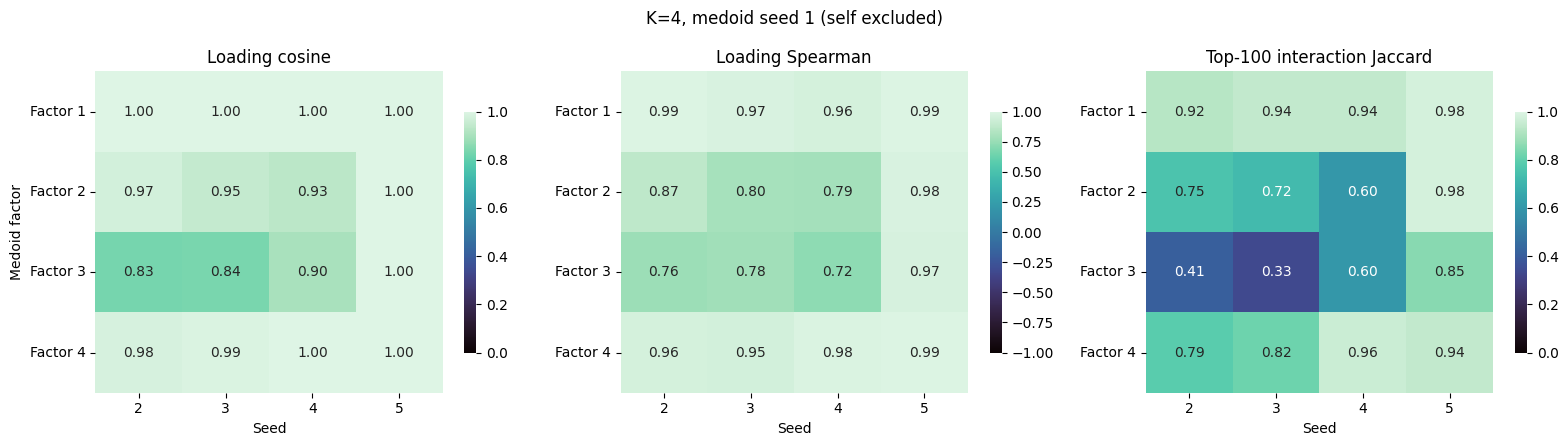

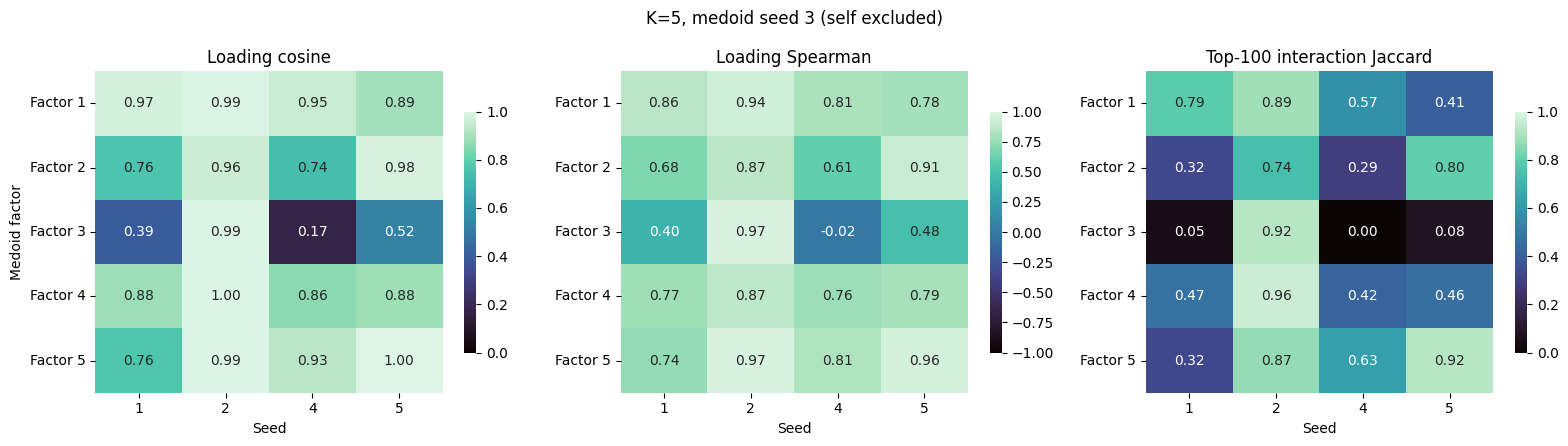

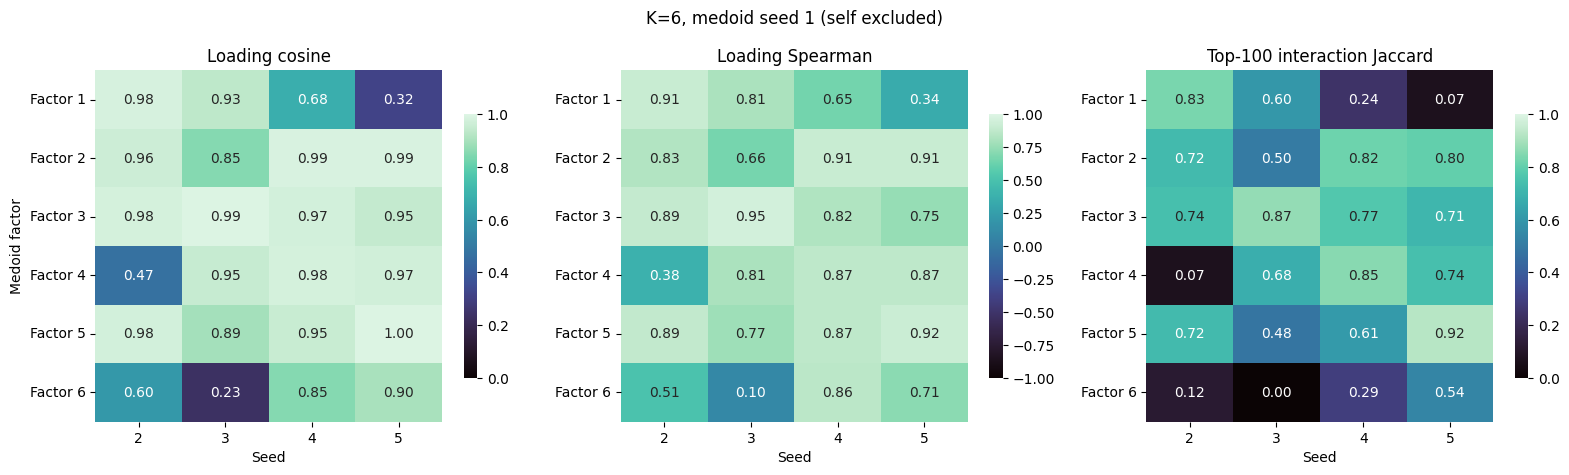

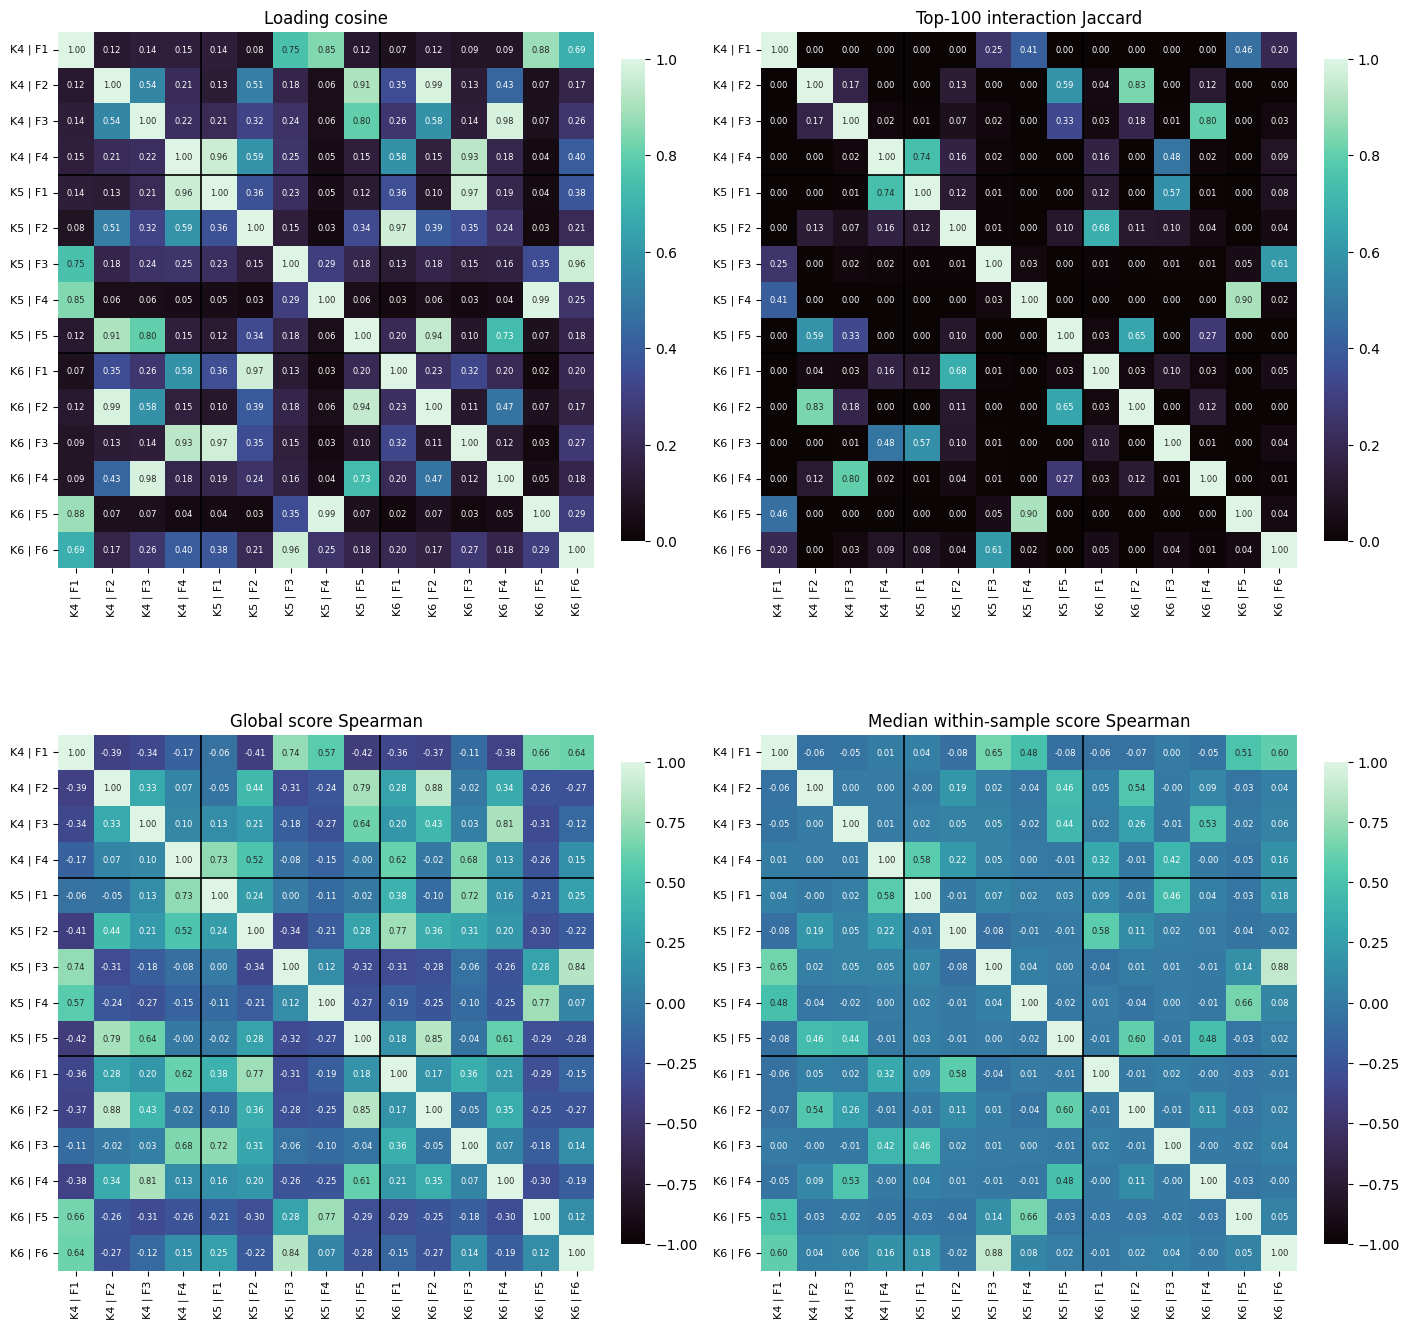

In [10]:
kgrid_results, _, stability_summary = analyse_kgrid_runs(
    kgrid_runs,
    kgrid_configs,
    min_cells_per_sample=10,
    top_n_interactions=100,
)

#display(stability_summary.drop(columns="reference_seed").sort_values(["K", "reference_factor"]))

# Fixed-K loading cosine, loading Spearman and top-interaction Jaccard
plot_seed_reproducibility_heatmaps(kgrid_results)

# Cross-K loading composition and factor-score relationships
medoid_matrices = build_medoid_factor_matrices(
    kgrid_results,
    min_cells_per_sample=10,
    top_n_interactions=100,
)
plot_medoid_factor_heatmaps(medoid_matrices)

## K=4 medoid interpretation

The following cells use all four factors from one dynamically selected medoid run. No factors are mixed across seeds.

In [ ]:
k4_result = kgrid_results[4]
k4_display_seed = k4_result["reference_seed_label"]
k4_run = k4_result["reference_run"]
k4_factor_scores = k4_run["factor_scores"].copy()
k4_all_weights = k4_run["all_weights"].copy()
k4_factors = k4_result["reference_factors"]

print(f"K=4 medoid: seed {k4_display_seed}")
print(k4_run["run_name"])
display(
    stability_summary.loc[stability_summary["K"] == 4]
    .drop(columns="reference_seed")
    .sort_values("reference_factor")
)

K=4 medoid: seed 1
inflow_leiden_sampleblocked_bw150_prev001_sendercap300_k4_nmf_seed11


,K,reference_seed_label,reference_factor,independent_runs,independent_runs_passing_all,stable,median_weight_cosine,minimum_weight_cosine,median_weight_spearman,median_global_score_spearman,median_within_sample_spearman,median_top_interaction_jaccard
0,4,1,Factor 1,4,4,True,0.998225,0.996703,0.979375,0.914831,0.936761,0.941748
1,4,1,Factor 2,4,0,False,0.961876,0.932866,0.833325,0.831392,0.450081,0.739262
2,4,1,Factor 3,4,0,False,0.868572,0.829455,0.771407,0.649384,0.426686,0.504225
3,4,1,Factor 4,4,0,False,0.995028,0.984082,0.968974,0.836106,0.588181,0.879965


,factor,feature,weight
0,Factor 1,8^APP^LRP1,5.830907
1,Factor 1,17^PTN^PTPRS,5.620761
2,Factor 1,17^SPON1^APP,5.393620
3,Factor 1,25^SLIT2^APP,5.196948
4,Factor 1,8^APP^LRP6,5.134467
5,Factor 2,6^BCAN^EGFR,6.724300
6,Factor 2,6^PTN^PTPRS,6.511631
7,Factor 2,6^TNC^PTPRZ1,6.415915
8,Factor 2,6^TNC^EGFR,6.231270
9,Factor 2,6^PTN^PTPRZ1,6.193017


,Factor 1,Factor 2,Factor 3,Factor 4
receiver_leiden,,,,
epen_ciliated_astroRG (L0),-0.119044,-0.105016,-0.136436,-0.186006
neurodev_stemlike_malignant (L1),-0.202187,-0.190246,-0.029789,-0.302948
macrophages (L3),-0.101677,-0.324117,-0.316063,0.211484
epen-astroRG-ciliated_earlyreactive (L4),-0.456541,-0.184801,-0.178930,-0.189387
EGFR_GPClike_malignant (L6),-0.317386,0.023581,-0.122690,-0.126048
EGFR_PDGFRA_malignant (L7),-0.423365,-0.333374,0.169041,-0.223878
mesenchymal_inflam_malignant (L9),-0.312245,-0.204044,-0.151784,0.271357
microglia (L10),0.705961,-0.391593,-0.412670,-0.090798
endothelial (L11),0.858904,-0.273171,-0.273572,-0.010479


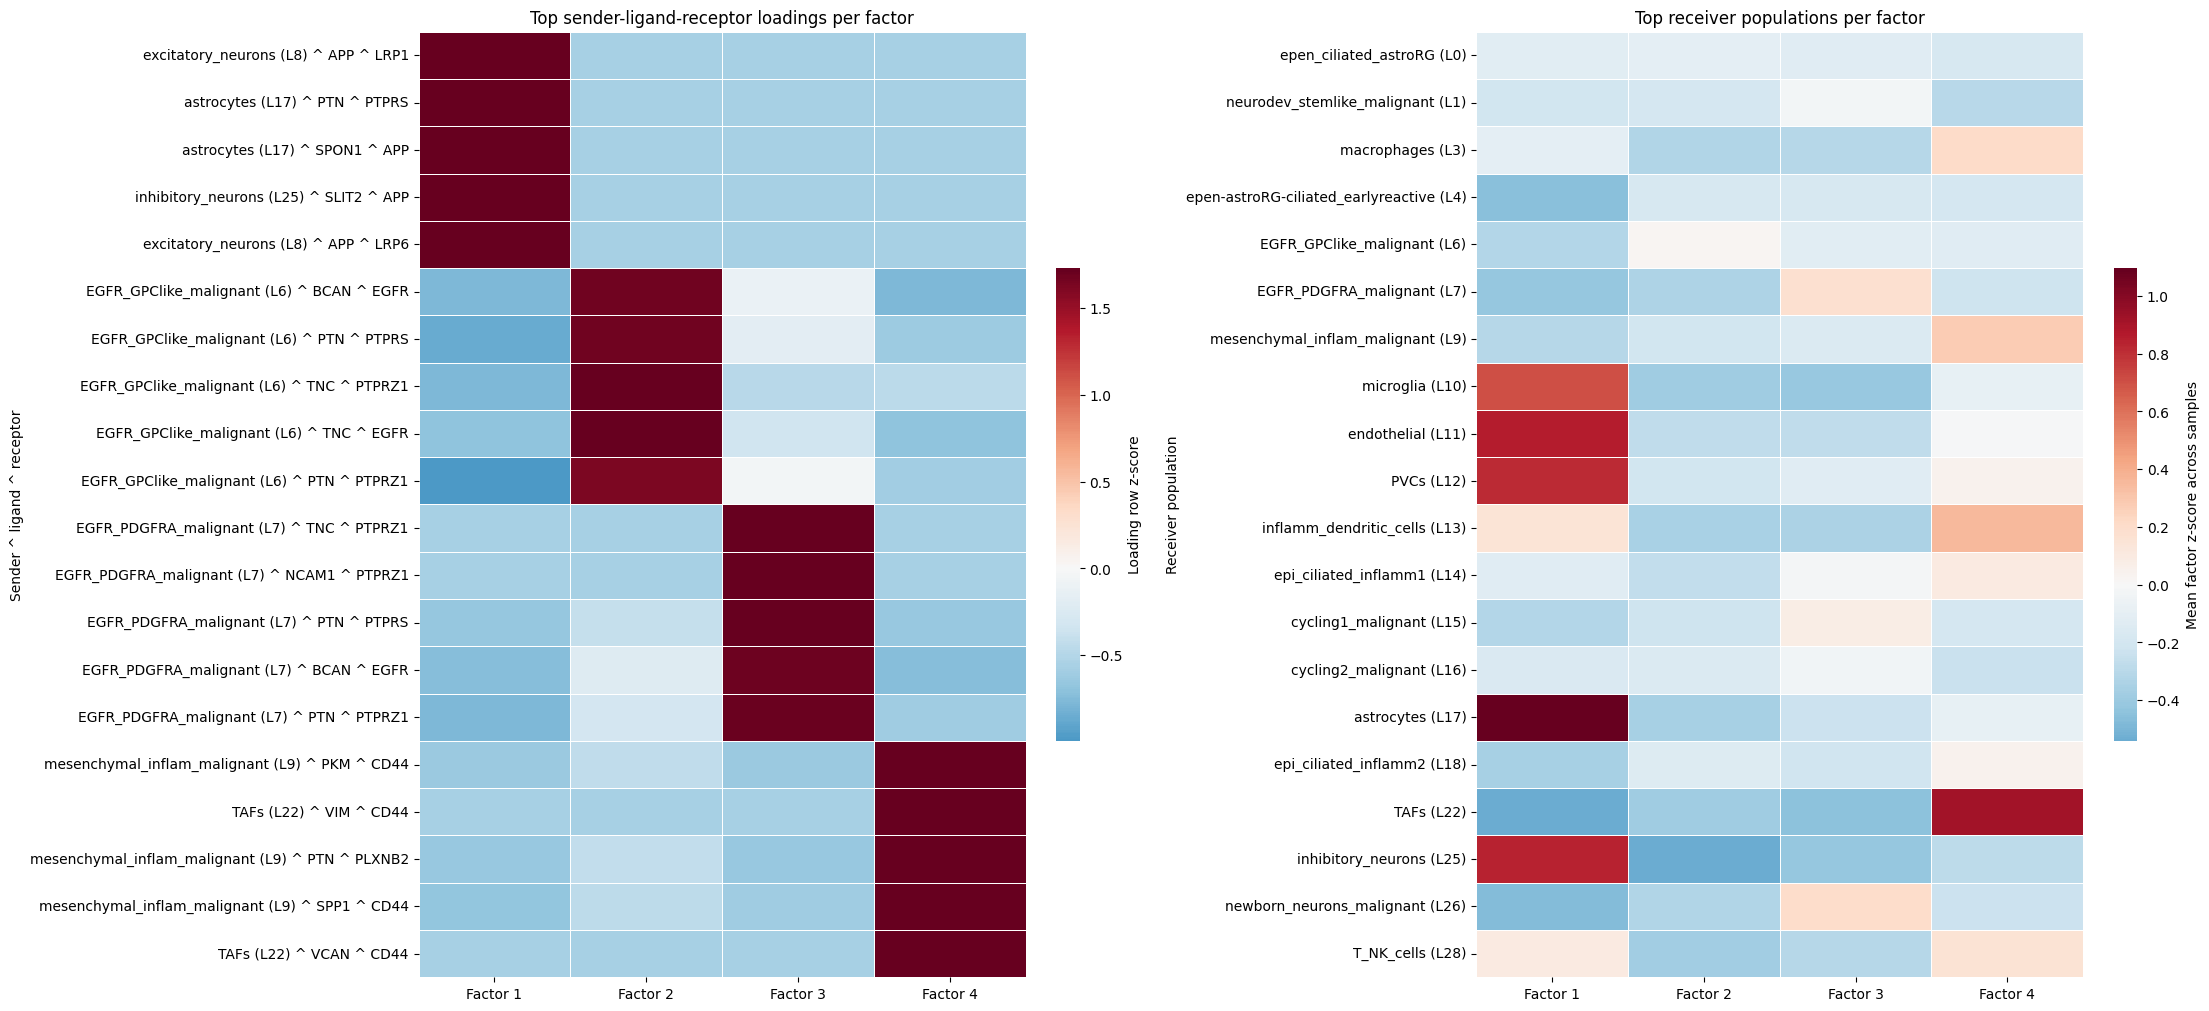

In [9]:
# Top sender-ligand-receptor loadings and top receiver populations per factor.
import matplotlib.pyplot as plt

top_interactions_per_factor = 5
top_receivers_per_factor = 5

loading_matrix = (
    k4_all_weights.pivot_table(
        index=["view", "feature"],
        columns="factor",
        values="weight",
        aggfunc="first",
        fill_value=0.0,
    )
    .reindex(columns=k4_factors, fill_value=0.0)
)

top_loading_rows = []
for factor in k4_factors:
    top = loading_matrix.loc[loading_matrix[factor] > 0, factor].nlargest(
        top_interactions_per_factor
    )
    table = top.rename("weight").reset_index()
    table["factor"] = factor
    top_loading_rows.append(table)
top_loadings = pd.concat(top_loading_rows, ignore_index=True)
display(top_loadings[["factor", "feature", "weight"]])

selected_interactions = list(
    dict.fromkeys(zip(top_loadings["view"], top_loadings["feature"]))
)
loading_plot = loading_matrix.reindex(selected_interactions)
loading_plot = loading_plot.sub(loading_plot.mean(axis=1), axis=0).div(
    loading_plot.std(axis=1, ddof=0).replace(0, np.nan), axis=0
).fillna(0)

cluster_column = "receiver_leiden"
cell_type_column = "receiver_cell_type"
annotation = (
    k4_factor_scores[[cluster_column, cell_type_column]]
    .dropna()
    .astype(str)
    .value_counts()
    .rename("n")
    .reset_index()
    .sort_values("n", ascending=False)
    .drop_duplicates(cluster_column)
    .set_index(cluster_column)[cell_type_column]
)

interaction_labels = []
for _, feature in loading_plot.index:
    parts = str(feature).split("^", 2)
    if len(parts) == 3:
        sender, ligand, receptor = parts
        sender_name = annotation.get(sender, f"Leiden {sender}")
        interaction_labels.append(f"{sender_name} (L{sender}) ^ {ligand} ^ {receptor}")
    else:
        interaction_labels.append(str(feature))
loading_plot.index = interaction_labels

receiver_scores = k4_factor_scores[
    ["sample_id", cluster_column] + k4_factors
].copy()
receiver_scores[cluster_column] = receiver_scores[cluster_column].astype(str)
receiver_scores[k4_factors] = receiver_scores[k4_factors].apply(pd.to_numeric)
receiver_scores[k4_factors] = receiver_scores[k4_factors].sub(
    receiver_scores[k4_factors].mean()
).div(receiver_scores[k4_factors].std(ddof=0).replace(0, np.nan))

receiver_activity = (
    receiver_scores.groupby(["sample_id", cluster_column], observed=True)[k4_factors]
    .mean()
    .groupby(cluster_column, observed=True)
    .mean()
)
receiver_labels = {
    cluster: f"{annotation.get(cluster, 'Unknown').replace('_', '_')} (L{cluster})"
    for cluster in receiver_activity.index
}
selected_receivers = list(
    dict.fromkeys(
        cluster
        for factor in k4_factors
        for cluster in receiver_activity[factor].nlargest(top_receivers_per_factor).index
    )
)

selected_receivers = sorted(selected_receivers, key=int)
receiver_plot = receiver_activity.loc[selected_receivers].rename(index=receiver_labels)
display(receiver_plot)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(22, max(10, 0.45 * max(len(loading_plot), len(receiver_plot)))),
    constrained_layout=True,
)
sns.heatmap(
    loading_plot,
    cmap="RdBu_r",
    center=0,
    linewidths=0.4,
    cbar_kws={"label": "Loading row z-score", "shrink": 0.5},
    ax=axes[0],
)
axes[0].set_title("Top sender-ligand-receptor loadings per factor")
axes[0].set_xlabel("")
axes[0].set_ylabel("Sender ^ ligand ^ receptor")

sns.heatmap(
    receiver_plot,
    cmap="RdBu_r",
    center=0,
    linewidths=0.4,
    cbar_kws={"label": "Mean factor z-score across samples", "shrink": 0.5},
    ax=axes[1],
)
axes[1].set_title("Top receiver populations per factor")
axes[1].set_xlabel("")
axes[1].set_ylabel("Receiver population")
plt.show()

## Saving MOFA factors for STORMI (K=4)

In [7]:
metadata_columns = [
    column
    for column in [
        "metacell_id",
        "sample_id",
        "patient",
        "region",
        "leiden",
        "receiver_leiden",
        "cell_type",
        "receiver_cell_type",
    ]
    if column in k4_factor_scores
]
stormi_covariates = k4_factor_scores[metadata_columns + k4_factors].copy()

stormi_dir = Path("/g/stegle/tovar/notebooks_stormi/stormi_inputs")
stormi_dir.mkdir(parents=True, exist_ok=True)
output_stem = f"{k4_run['run_name']}_medoid_metacell_covariates"
parquet_path = stormi_dir / f"{output_stem}.parquet"
csv_path = stormi_dir / f"{output_stem}.csv"
stormi_covariates.to_parquet(parquet_path, index=False)
stormi_covariates.to_csv(csv_path, index=False)

print(f"Saved K=4 medoid seed {k4_display_seed}: {stormi_covariates.shape}")
print(parquet_path)
print(csv_path)

Saved K=4 medoid seed 1: (88088, 12)
/g/stegle/tovar/notebooks_stormi/stormi_inputs/inflow_leiden_sampleblocked_bw150_prev001_sendercap300_k4_nmf_seed11_medoid_metacell_covariates.parquet
/g/stegle/tovar/notebooks_stormi/stormi_inputs/inflow_leiden_sampleblocked_bw150_prev001_sendercap300_k4_nmf_seed11_medoid_metacell_covariates.csv
